In [1]:
import sys, subprocess, shutil, pygmt
from pathlib import Path
import xarray as xr
import numpy  as np
import pandas as pd
from IPython.display import Video, Image, display
#####################################################################
# make sure this reflects the correct location of mawsons-chest repo
repo_root = Path.home() / "AFIM" / "src" / "mawsons-chest"
#####################################################################
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

<xarray.Dataset> Size: 5GB
Dimensions:   (t_FI_obs: 432, nj: 1080, ni: 1440)
Coordinates:
  * t_FI_obs  (t_FI_obs) datetime64[ns] 3kB 2000-03-01 2000-03-16 ... 2018-02-15
Dimensions without coordinates: nj, ni
Data variables:
    FI        (t_FI_obs, nj, ni) float64 5GB dask.array<chunksize=(27, 68, 180), meta=np.ndarray>
    FI_t_alt  (t_FI_obs) int32 2kB dask.array<chunksize=(432,), meta=np.ndarray>


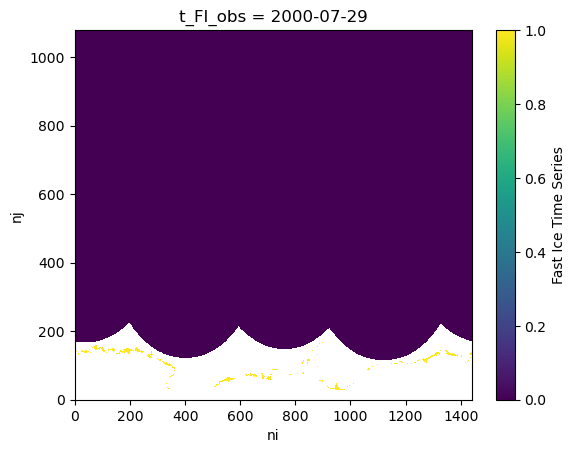

In [5]:
ds = xr.open_zarr("/g/data/gv90/da1339/SeaIce/FI_obs/AF-FI-2020db_org-timestep_reG.zarr", consolidated=False)
print(ds)
ds['FI'].isel(t_FI_obs=10).plot()

In [10]:
import shuga
from shuga import configs 
from shuga import loaders 
from shuga import regions 
sim_name     = "LD-fsnow-red"
START        = "1993-01-01"
END          = "1993-12-31"
ICE_TYPE     = "FI"
METHOD       = "binary-days"
FLD_NAME     = "FIHI"
REG_NAME     = "BS"
FIG_SIZE     = 15
GRD_STY      = "c0.15c"
MOS          = [4,5,6]
REG_PLOT     = regions.ANTARCTIC_8_REGIONS[REG_NAME]["plot_region"]
pth_cfg      = configs.ShugaPaths(lateral_drag = configs.LateralDragSpec())#combined_form_factors_file="/g/data/gv90/da1339/coastal_drag/form_factors/ADD_high-res_cstln_v7p9_GI_CICE_free-slip.nc"))
P_CPT_FIP    = pth_cfg.fip_cmap
P_F2         = pth_cfg.combined_form_factors_path
D_pub        = pth_cfg.graphics_root_path / "LD-pub-workspace"
D_s_f        = D_pub / sim_name / FLD_NAME
D_s_f_r      = D_s_f / REG_NAME
D_ts         = D_pub / "timeseries"
EXPS_SPD_GTE = ["LD-static-Cs1e-3",
                "LD-static-Cs5e-4",
                "LD-quad-Cq350",
                "LD-quad-Cq75",
                "LD-linear-CL0p25"]
EXPS_BLN_GTE = ["LD-blend-base",
                "LD-blend-exp10",
                "LD-blend-eDef-ktens0p1",
                "LD-blend-ef_lt_eg",
                "LD-blend-Cs7p5e-4"]
EXPS_ALL     = EXPS_SPD_GTE + EXPS_BLN_GTE
DYN_VARS     = ["aice", "hi", "tarea", "TLON", "TLAT", "uvel", "vvel", "uocn", "vocn",
                "divu", "shear", "sig1", "sig2", "sigP", "strength",
                "strairx", "strairy", "strocnx", "strocny", "strintx", "strinty", "strcorx", "strcory", "strtltx", "strtlty",
                "KuxE", "KuyE", "KuxN", "KuyN", "F2E", "F2N"]
PLT_FLD_DICT = {"FIP"       : {"series": [0.0, 1.0],
                               "cmap"  : P_CPT_FIP,
                               "frame" : ["a0.2f0.1", 'x+lpersistence']},
                "FIHI"      : {"series": [0.0, 5],    
                               "cmap"  : "cmocean/ice",
                               "frame" : ["xaf", 'x+lthickness', 'y+lm']},
                "FIST"      : {"series": [0.0, 10],
                               "cmap"  : "cmocean/dense",
                               "frame" : ["xaf", 'x+lstrength', "y+lMPa"]},
                "FI_Ku_p90" : {"series": [0.0, 3],
                               "cmap"  : "batlow",
                               "frame" : ["xaf", 'x+lstress', "y+l(N m@+-2@+)"]},
                "strain_p90": {"series": [0.0, 200],
                               "cmap"  : "cmocean/amp",
                               "frame" : ["xaf", 'x+lstrain', "y+l(10@+-6@+ s@+-1@+)"]},
                "FIMAR_YR"  : {"series": [-1, 1],
                               "cmap"  : "polar",
                               "frame" : ["xaf", 'x+lrate' , "y+lkm@+2@+ dy@+-1@+"]}}
print(P_F2)

/g/data/gv90/da1339/coastal_drag/form_factors/ADD_high-res_cstln_v7p9_GI_CICE_free-slip.nc


INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-fsnow-red [Tc/binary-days] by exact path: /home/581/da1339/AFIM_archive/LD-fsnow-red/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
INFO:shuga.io.zarr_loading:Opening metrics store for LD-fsnow-red [Tc/binary-days]: /home/581/da1339/AFIM_archive/LD-fsnow-red/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-06-05 10:44:57,580 - INFO - [shuga.plotting.plot_timeseries_multi:854] Loaded FIT for LD-fsnow-red using grid_type=Tc
INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-fsnow-sep [Tc/binary-days] by exact path: /home/581/da1339/AFIM_archive/LD-fsnow-sep/zarr/SH/ispd_thres

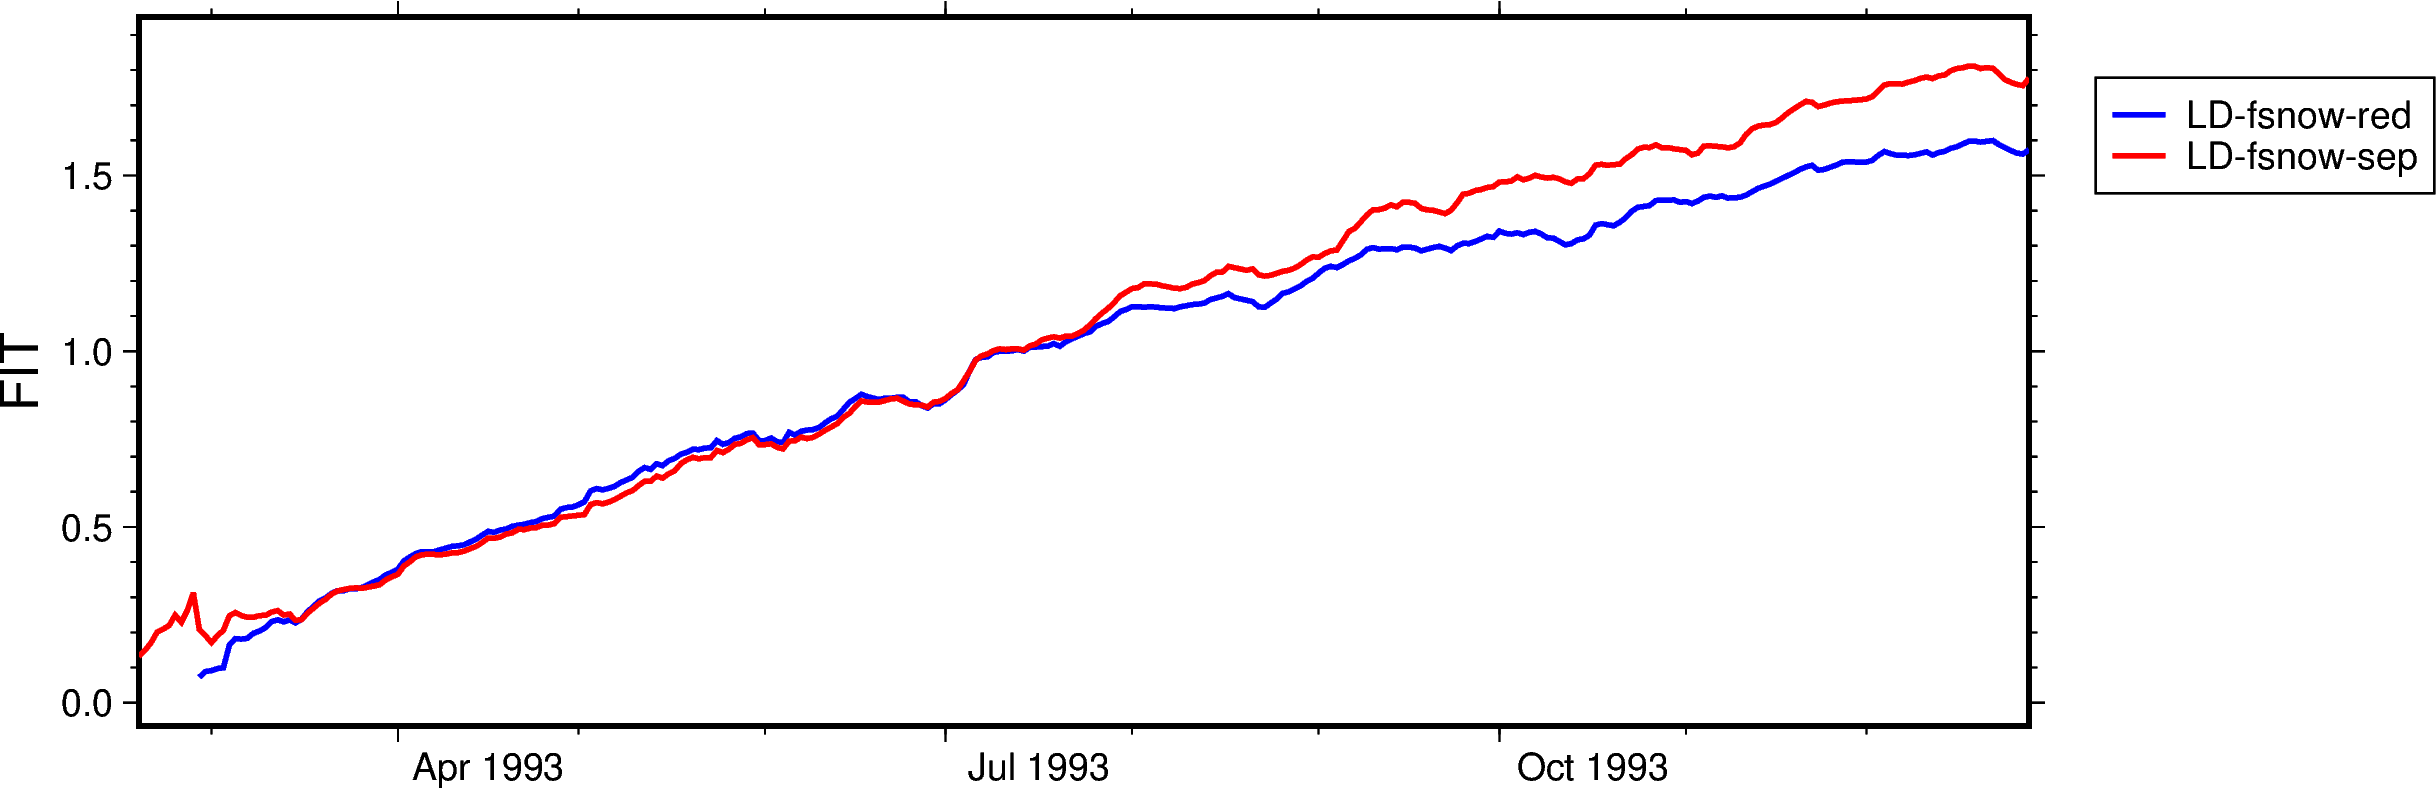

In [12]:
pltr = shuga.CICEPlotter(sim_name   = "LD-fsnow-red",
                         start_date = START,
                         end_date   = END,
                         ice_type   = ICE_TYPE,
                         method     = METHOD)
plt_var = "FIT"
plt_suf = "speed-gates"
P_fig   = pltr.plot_timeseries_multi(variable        = plt_var,
                                     method          = METHOD,
                                     simulations     = ['LD-fsnow-red','LD-fsnow-sep'],
                                     region          = "total",
                                     legend_position = "JMR+jCM+o2c",
                                     output_path     = str(Path(D_ts,f"{plt_var}_SH_LD-fsnow-both.png")),
                                     add_f2020       = False,
                                     f2020_mode      = "climatology")
display(Image(filename=P_fig))

2026-06-05 06:53:27,501 - INFO - [shuga.plotting.plot_timeseries:680] loading metrics for LD-fsnow-red over period 1993-01-01 -- 1993-12-31 for hemisphere SH ...
INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-fsnow-red [Tc/binary-days] by exact path: /home/581/da1339/AFIM_archive/LD-fsnow-red/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
INFO:shuga.io.zarr_loading:Opening metrics store for LD-fsnow-red [Tc/binary-days]: /home/581/da1339/AFIM_archive/LD-fsnow-red/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-06-05 06:53:27,833 - INFO - [shuga.plotting.plot_timeseries:722] constructing observational time-series
2026-06-05 06:53:27,834 - INFO - [shuga.plotting.plot_timeseries:761] creating figure
2026-06-05 06:53:27,850 - INFO - [shuga.plotting.plot_timeseries:777]      basemap
20

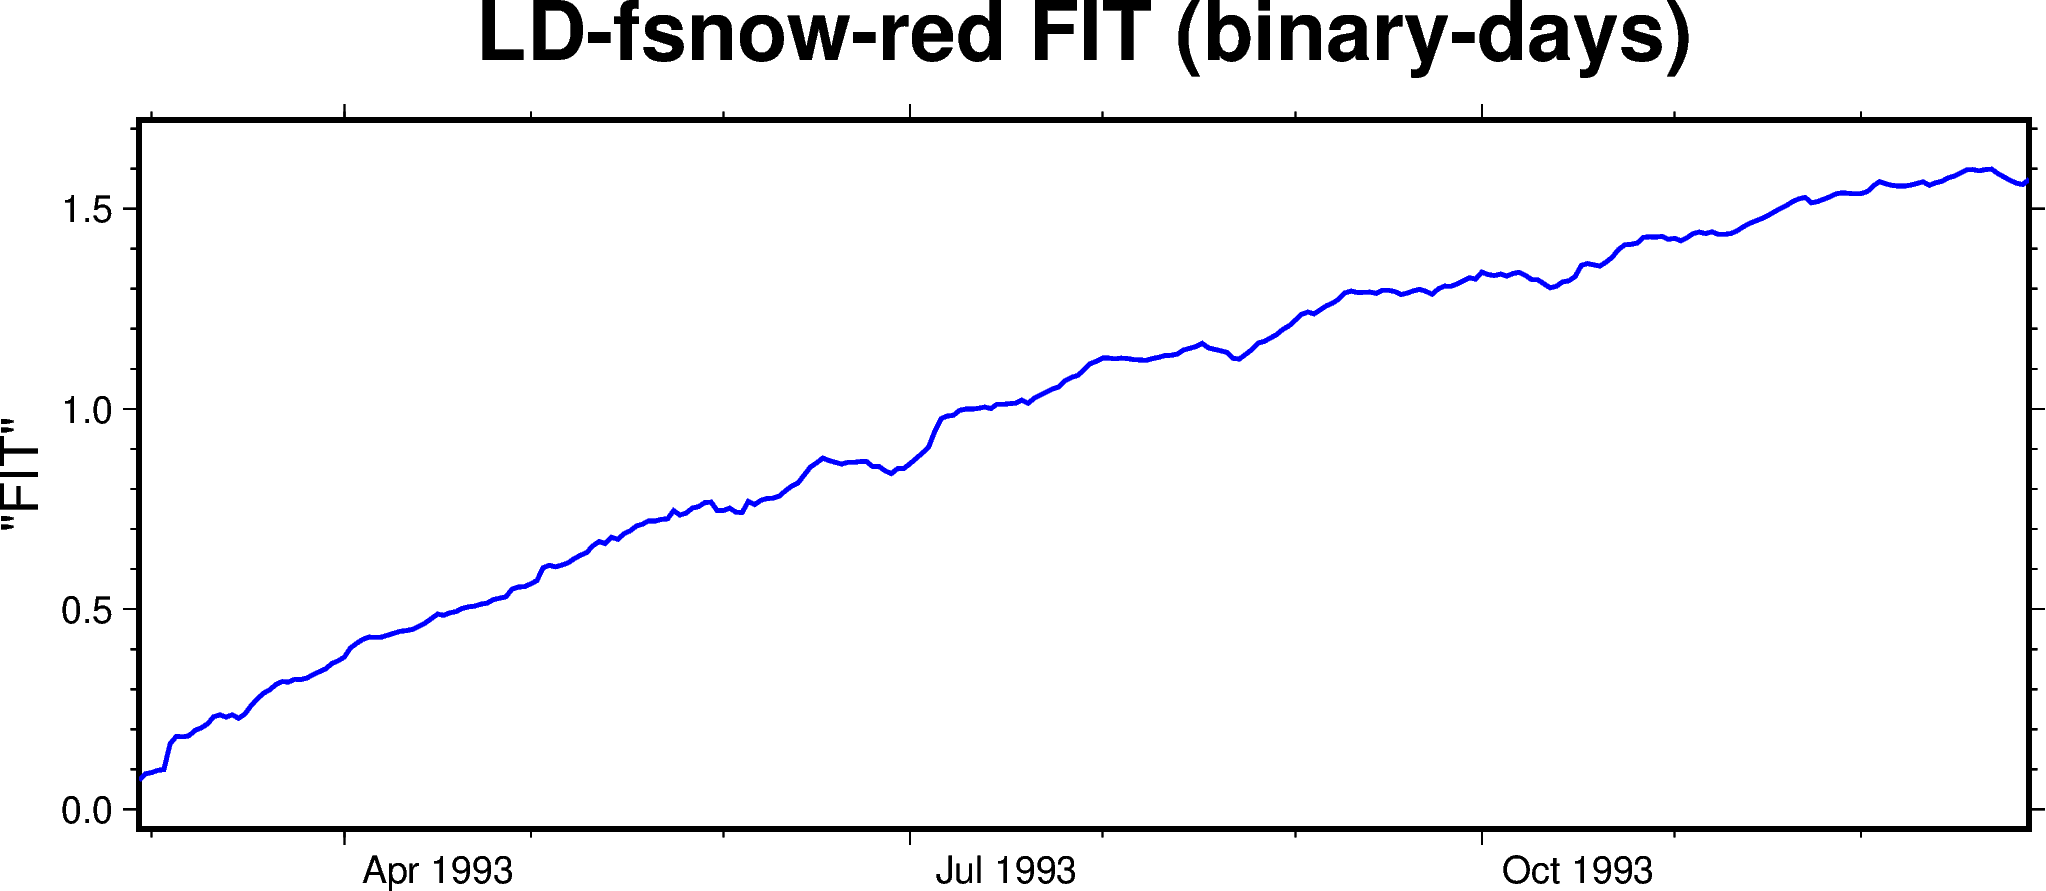

In [7]:
P_fig = pltr.plot_timeseries(variable        = "FIT",
                             method          = METHOD,
                             region          = "total",
                             output_path     = str(Path(D_ts,f"FIT_SH_LD-fsnow-red.png")),
                             add_f2020       = False,
                             f2020_mode      = "climatology")
display(Image(filename=P_fig))

In [2]:
from shuga import report_sim_status
report_sim_status(sim_name="LD-static-Cs5e-4")

Simulation: LD-static-Cs5e-4
Hemisphere: SH
Output root: /g/data/gv90/da1339/afim_output/LD-static-Cs5e-4
Zarr root: /g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr

CICE history store
  path: /g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr/iceh_daily.zarr
  exists: True
  coverage: 1994-09-01 -> 2003-12-31 (64 monthly groups, n_time=None)
  static store: /g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr/iceh_static.zarr
  static exists: True

Classifications
  1. binary-days [Tc]
     ice_type: FI
     ispd_thresh: 5.0e-4
     aice_thresh: 0.15
     binary-days: window=11, min_days=9
     class store: /g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr
     coverage: 1999-01-01 -> 2003-12-31 (n_time=1826)
     metrics: yes
     metrics health: healthy
  2. binary-days [Tc]
     ice_type: PI
     ispd_thresh: 5.0e-4
     aice_thresh: 0.15
     binary-days: window=11, min_days=9
     class store: /g/data/gv90/

SimulationStatusReport(sim_name='LD-static-Cs5e-4', hemisphere='SH', output_root='/g/data/gv90/da1339/afim_output/LD-static-Cs5e-4', zarr_root='/g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr', cice=CICEStoreStatus(path='/g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr/iceh_daily.zarr', exists=True, coverage=TimeCoverage(start_date='1994-09-01', end_date='2003-12-31', n_time=None, n_groups=64), static_store='/g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr/iceh_static.zarr', static_exists=True), classifications=[ClassificationStatus(method='binary-days', grid_type='Tc', classification_path='/g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/data.zarr', metrics_path='/g/data/gv90/da1339/afim_output/LD-static-Cs5e-4/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr', ice_type='FI', ispd_thresh='5.0e-4', aice_thresh=0.15, bin_window=11, bin_min_days=9, roll_window=None, coverage=TimeCoverage(start_date='19

# load CICE (`raw`) and FI classified (`binary-days`) 

In [3]:
from shuga import (RunSpec, ClassificationSpec, CICEClassifier)
from shuga import load_cice, load_classified
run      = RunSpec(sim_name="LD-static-Cs1e-3", start_date="2000-01-01", end_date="2003-12-31", hemisphere="SH")
classify = ClassificationSpec(ice_type="FI", grid_type="Tc", ispd_thresh=5e-4, methods=("binary-days","rolling-mean"), bin_window=11, bin_min_days=9)
CICE     = load_cice(run, variables=['aice','hi','uvel','vvel','uocn','vocn','uatm','vatm','strength','strairx','strairy','strintx','strinty'])

INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Opening grouped monthly CICE Zarr between 2000-01-01 00:00:00 and 2003-12-31 00:00:00 (48 groups)
INFO:shuga.io.zarr_loading:Opening group 2000-01 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-02 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-03 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-04 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-05 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-06 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-07 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-08 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-09 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening group 2000-10 with chunks={'time': 31}
INFO:shuga.io.zarr_loading:Opening gr

## ice speed from fast ice and pack ice

In [ ]:
FF      = xr.open_dataset("/g/data/gv90/da1339/coastal_drag/form_factors/ADD_high-res_cstln_v7p9_GI_CICE_free-slip.nc")
F2_mag  = np.hypot(FF["F2x"], FF["F2y"])
F2_mask = xr.where(F2_mag > 0.0, 1.0, 0.0)
ispd    = np.hypot(CICE['uvel'],CICE['vvel'])
FI_ispd = ispd.where(FI_mask)
PI_ispd = ispd.where(~FI_mask)
SP      = CICEPlotter(run, classify)
region  = 'Aus'
var_name = "FI_ispd"
D_out   = Path.home() / "graphical" / "AFIM" / SP.run.sim_name / region / var_name
D_out.mkdir(parents=True, exist_ok=True)
regions = SP._resolve_regions()
reg     = regions[region]
proj    = SP.projection_from_region(reg)
coords  = SP._load_static_lonlat()
lon2d   = coords["TLON"].values
lat2d   = coords["TLAT"].values
z2d     = F2_mask.values
m       = np.isfinite(lon2d) & np.isfinite(lat2d) & np.isfinite(z2d)
for t_ind in np.arange(330,366):
    tstamp  = f"{pd.to_datetime(FI_ispd['time'].values[t_ind]):%Y-%m-%d}"
    P_out   = D_out / f"{tstamp}.png"
    if P_out.exists():
        print(f"file exists {P_out} ... skipping overwrite")
        continue
    plt_FI  = SP.pygmt_da_prep(FI_ispd.isel(time=t_ind), lon=coords['TLON'], lat=coords['TLAT'], region=reg)
    plt_PI  = SP.pygmt_da_prep(PI_ispd.isel(time=t_ind), lon=coords['TLON'], lat=coords['TLAT'], region=reg)
    fig     = pygmt.Figure()
    SP.pygmt_base_layer(fig, reg, proj, title=tstamp)
    pygmt.makecpt(cmap="cmocean/amp", series=[0,0.0005], reverse=True)
    fig.plot(x=plt_FI["lon"], y=plt_FI["lat"], style="c0.125c", fill=plt_FI["z"], cmap=True)
    fig.colorbar(position=SP.plotting.colorbar_position, frame=["a0.0005f0.0001", "x+lfast (bin-days) ice speed", "y+lm/s"])
    pygmt.makecpt(cmap="cmocean/speed", series=[0.0005,1])
    fig.plot(x=plt_PI["lon"], y=plt_PI["lat"], style="c0.15c", fill=plt_PI["z"], cmap=True)
    fig.colorbar(position="JMR+w8c/0.4c+v+o0.8c/0c", frame=["a0.1f0.05", "x+lpack ice speed", "y+lm/s"])
    fig.contour(x=lon2d[m], y=lat2d[m], z=z2d[m], levels=[1], pen=".5p,blue")
    fig.savefig(P_out)
    print(f"wrote file to {P_out}")
    #display(Image(filename=P_out))

In [ ]:
fps   = 4
D_png = D_out
D_tmp = Path("/g/data/gv90/da1339/tmp") / f"{SP.run.sim_name}_{region}_{var_name}_frames"
D_ani = Path.home() / "graphical" / "AFIM" / "animations" / SP.run.sim_name / region / var_name
D_tmp.mkdir(parents=True, exist_ok=True)
D_ani.mkdir(parents=True, exist_ok=True)
frames = sorted(D_png.glob("*.png"))
assert frames, f"No frames found in {D_png}"
# clear any old numbered frames
for old in D_tmp.glob("frame_*.png"):
    old.unlink()
# create numbered symlinks (or use shutil.copy2 if symlinks are awkward on your system)
for i, frame in enumerate(frames):
    target = D_tmp / f"frame_{i:04d}.png"
    target.symlink_to(frame)
dt0   = pd.to_datetime(frames[0].stem)
dtN   = pd.to_datetime(frames[-1].stem)
P_ani = D_ani / f"{dt0:%Y-%m-%d}_to_{dtN:%Y-%m-%d}_{SP.run.sim_name}_{region}_{var_name}.mp4"
cmd   = ["ffmpeg", "-y", "-framerate", str(fps), "-i", str(D_tmp / "frame_%04d.png"),
         "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2,format=yuv420p", "-c:v", "libx264", "-pix_fmt", "yuv420p",
         "-movflags", "+faststart", str(P_ani)]
subprocess.run(cmd, check=True)
print(f"Created: {P_ani}")

In [ ]:
display(Video(str(P_ani), embed=True, html_attributes="controls loop"))

## Helpers

In [ ]:
def vector_df(u: xr.DataArray, v: xr.DataArray, lon: xr.DataArray, lat: xr.DataArray, region, *,
              stride: int,
              min_mag: float,
              scale_cm_per_ms: float,
              max_len_cm     : float = 1,) -> pd.DataFrame:
    """
    Build a PyGMT vector table with columns:
    lon, lat, angle_deg, length_cm

    angle is the TO direction:
    - eastward flow  => 0 deg
    - northward flow => 90 deg
    """
    u_s       = u.isel(nj=slice(None, None, stride), ni=slice(None, None, stride))
    v_s       = v.isel(nj=slice(None, None, stride), ni=slice(None, None, stride))
    lon_s     = lon.isel(nj=slice(None, None, stride), ni=slice(None, None, stride))
    lat_s     = lat.isel(nj=slice(None, None, stride), ni=slice(None, None, stride))
    reg_mask  = SP._region_mask(lon_s, lat_s, region)
    mag       = np.hypot(u_s, v_s)
    ang       = np.degrees(np.arctan2(v_s, u_s))   # TO direction
    length_cm = np.clip(mag * scale_cm_per_ms, 0.08, max_len_cm)
    good      = (reg_mask.values.ravel() & np.isfinite(mag.values.ravel()) & np.isfinite(ang.values.ravel()) & (mag.values.ravel() >= min_mag))
    df        = pd.DataFrame({"lon": SP._lon_to_180(lon_s).values.ravel(),
                              "lat": lat_s.values.ravel(),
                              "ang": ang.values.ravel(),
                              "len": length_cm.values.ravel(),
                              "mag": mag.values.ravel()})
    return df.loc[good].reset_index(drop=True)

def plot_vector_panel(fig, df: pd.DataFrame):
    if df.empty:
        return
    fig.plot(data          = df[["lon", "lat", "ang", "len"]].to_numpy(),
             style         = "v0.16c+e+a28+h0.35+p0.35p,black",
             pen           = "0.35p,black",
             fill          = "black",
             straight_line = True)

def add_vector_scale(fig, *, ref_speed_ms: float, scale_cm_per_ms: float, label: str, panel_width_cm: float,
                     ann_height_cm: float = 2,
                     font: str = "20p,Helvetica,black"):
    """
    Draw a horizontal reference vector + label in a small annotation strip
    directly below the current panel.
    """
    ref_len_cm = ref_speed_ms * scale_cm_per_ms
    # center the arrow in the annotation strip
    x0 = 0.5 * (panel_width_cm - ref_len_cm)
    y0 = 0.58
    fig.shift_origin(yshift=f"-{ann_height_cm}c")
    fig.basemap(region=[0, panel_width_cm, 0, 1], projection=f"X{panel_width_cm}c/{ann_height_cm}c", frame='+tscale')
    fig.plot(data=np.array([[x0, y0, 0.0, ref_len_cm]]),
             style="v0.20c+e+a28+h0.35+p0.45p,black",
             pen="0.45p,black",
             fill="black",
             straight_line=True)
    fig.text(x=panel_width_cm/2, y=1, text=label, justify="TC", font=font)
    fig.shift_origin(yshift=f"{ann_height_cm}c")

## plot stresses for a region

In [ ]:
from shuga import CICEPlotter
from shuga.core.naming import normalize_method
# ------------------------------------------------------------
# Assumptions:
# - CICE is already loaded and contains:
#   uvel, vvel, uocn, vocn, uatm, vatm
# - run / classify already exist
# - new classified store contains FI_mask and FI_ispd
# ------------------------------------------------------------
method    = "binary-days"   # or normalize_method(classify.methods[0])
SP        = CICEPlotter(run, classify)
region    = "Aus"
var_name  = "ocn_ice_wind"
overwrite = True
figsize   = 20
D_out     = Path.home() / "graphical" / "AFIM" / SP.run.sim_name / region / var_name
D_out.mkdir(parents=True, exist_ok=True)
regions   = SP._resolve_regions()
reg       = regions[region]
coords    = SP._load_static_lonlat()
proj      = SP.projection_from_region(reg, fig_size=figsize)
# ------------------------------------------------------------
# Load classified fields from data.zarr
# ------------------------------------------------------------
cls     = load_classified(run=run, classify=classify, classification=method,
                          dt0_str=str(pd.to_datetime(CICE.time.values[0]).date()),
                          dtN_str=str(pd.to_datetime(CICE.time.values[-1]).date()),
                          variables=["FI_mask", "FI_ispd"],
                          hemisphere=run.hemisphere,
                          chunks={"time": 31})
FI_mask = cls["FI_mask"].astype(bool)
FI_ispd = cls["FI_ispd"]
# align once so masks/speeds/CICE are on the same time index
# hs when present
FI_mask, FI_ispd, aice, hi, uvel, vvel, ist, strairx, strairy, strintx, strinty = xr.align(FI_mask, FI_ispd, CICE['aice'], CICE['hi'],
                                                                                     CICE["uvel"], CICE["vvel"],
                                                                                     CICE['strength'],
                                                                                     CICE['strairx'], CICE['strairy'],
                                                                                     CICE['strintx'], CICE['strinty'], join="inner")
#                                                                                     CICE['wave_sig_ht'], join="inner")
PI_ispd = np.hypot(uvel, vvel).where(~FI_mask)
FIST    = ist.where(FI_mask)
PIST    = ist.where(~FI_mask)
FIstrA  = np.hypot(strairx, strairy).where(FI_mask)
FIstrI  = np.hypot(strintx, strinty).where(FI_mask)
PIstrA  = np.hypot(strairx, strairy).where(~FI_mask)
PIstrI  = np.hypot(strintx, strinty).where(~FI_mask)

# ------------------------------------------------------------
# Static F2 outline
# Use 2D contouring at 0.5 rather than flattened scattered points
# ------------------------------------------------------------
FF          = xr.open_dataset("/g/data/gv90/da1339/coastal_drag/form_factors/ADD_high-res_cstln_v7p9_GI_CICE_free-slip.nc")#ADD_high-res_cstln_v7p9_GI_ocean_hgrid.nc")
F2_mag      = np.hypot(FF["F2x"], FF["F2y"])
F2_mask     = xr.where(F2_mag > 0.0, 1.0, 0.0)
f2_reg_mask = SP._region_mask(coords["TLON"], coords["TLAT"], reg)
F2_plot     = xr.where(f2_reg_mask, F2_mask, np.nan)
lon2d       = SP._lon_to_180(coords["TLON"]).values
lat2d       = coords["TLAT"].values
z2d         = F2_plot.values
m           = np.isfinite(lon2d) & np.isfinite(lat2d) & np.isfinite(z2d)

# ------------------------------------------------------------
# Fixed vector scaling for animation consistency
# Tweak these if arrows are too short/long
# ------------------------------------------------------------
curr_stride          = 5
curr_min_mag         = 0.01
curr_scale_cm_per_ms = 5.0
wind_stride          = 10
wind_min_mag         = 1.0
wind_scale_cm_per_ms = 0.5
# ------------------------------------------------------------
# Loop over frames
# ------------------------------------------------------------
for t_ind in np.arange(272, 273):
    tstamp = f"{pd.to_datetime(FI_ispd['time'].values[t_ind]):%Y-%m-%d}"
    P_out  = D_out / f"{tstamp}.png"
    if P_out.exists() and not overwrite:
        print(f"file exists {P_out} ... skipping overwrite")
        continue
    # -------------------------
    # colobar figures
    # -------------------------
    plt_FI = SP.pygmt_da_prep(FI_ispd.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    plt_PI = SP.pygmt_da_prep(PI_ispd.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    plt_aice = SP.pygmt_da_prep(aice.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    plt_FIST = SP.pygmt_da_prep(FIST.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    plt_PIST = SP.pygmt_da_prep(PIST.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    plt_FIstrI = SP.pygmt_da_prep(FIstrI.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    plt_FIstrA = SP.pygmt_da_prep(FIstrA.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    plt_PIstrI = SP.pygmt_da_prep(PIstrI.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    plt_PIstrA = SP.pygmt_da_prep(PIstrA.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    # -------------------------
    # left panel: ocean currents
    # -------------------------
    ocn_df = vector_df(CICE["uocn"].isel(time=t_ind), CICE["vocn"].isel(time=t_ind), coords["TLON"], coords["TLAT"], reg,
                       stride          = curr_stride,
                       min_mag         = curr_min_mag,
                       scale_cm_per_ms = curr_scale_cm_per_ms)
    # -------------------------
    # right panel: near-sfc wind
    # -------------------------
    wnd_df = vector_df(CICE["uatm"].isel(time=t_ind), CICE["vatm"].isel(time=t_ind), coords["TLON"], coords["TLAT"], reg,
                       stride          = wind_stride,
                       min_mag         = wind_min_mag,
                       scale_cm_per_ms = wind_scale_cm_per_ms)
    # ==========================================
    # Panel 1: ocean currents
    # ==========================================
    fig = pygmt.Figure()
    SP.pygmt_base_layer(fig, reg, proj, title="ocean current (forcing)")
    plot_vector_panel(fig, ocn_df)
    add_vector_scale(fig, ref_speed_ms=.5, scale_cm_per_ms=curr_scale_cm_per_ms, label="0.5 m/s", panel_width_cm=figsize)
    # ==========================================
    # Panel 2: ice speeds
    # ==========================================
    fig.shift_origin(xshift="w+1c")
    SP.pygmt_base_layer(fig, reg, proj, title=tstamp)
    pygmt.makecpt(cmap="cmocean/amp", series=[0, 0.0005], reverse=True)
    fig.plot(x=plt_FI["lon"], y=plt_FI["lat"], style="c0.125c", fill=plt_FI["z"], cmap=True)
    fig.colorbar(position="JMB+w9c/.5c+o0c/-.5c", frame=["a0.0001f0.00005", "x+lfast ice speed", "y+lm/s"])
    pygmt.makecpt(cmap="cmocean/speed", series=[0.0005, 1])
    fig.plot(x=plt_PI["lon"], y=plt_PI["lat"], style="c0.15c", fill=plt_PI["z"], cmap=True)
    fig.colorbar(position="JMB+w9c/0.5c+o0c/1.5c", frame=["a0.1f0.05", "x+lpack ice speed", "y+lm/s"])
    fig.contour(x=lon2d[m], y=lat2d[m], z=z2d[m], levels=[0.5], pen="0.6p,blue")
    # ==========================================
    # Panel 3: near-surface wind
    # ==========================================
    fig.shift_origin(xshift="w+1c")
    SP.pygmt_base_layer(fig, reg, proj, title="U10 (forcing; blowing-TO)")
    plot_vector_panel(fig, wnd_df)
    add_vector_scale(fig, ref_speed_ms=5, scale_cm_per_ms=wind_scale_cm_per_ms, label="5 m/s", panel_width_cm=figsize)
    # pygmt.makecpt(cmap="cmocean/ice", series=[0,1], reverse=False)
    # fig.plot(x=plt_aice["lon"], y=plt_aice["lat"], style="c0.125c", fill=plt_aice["z"], cmap=True)
    # fig.colorbar(position="JMB+w9c/.5c+o0c/-.5c", frame=["a0.1f0.05", "x+lice conentration", "y+l1/100"])
    # ==========================================
    # Bottom row: start from under the LEFT panel
    # (we are currently at the top-right wind panel)
    # ==========================================
    fig.shift_origin(yshift="-h-10c", xshift="-1.85w-5.5c", )
    # ==========================================
    # Panel 4: FIstrI below ocean currents
    # ==========================================
    SP.pygmt_base_layer(fig, reg, proj, title="Internal Ice Stress")
    pygmt.makecpt(cmap="cmocean/amp", series=[0, 10])
    fig.plot(x=plt_FIstrI["lon"], y=plt_FIstrI["lat"], style="c0.125c", fill=plt_FIstrI["z"], cmap=True)
    fig.colorbar(position="JMB+w9c/0.5c+o0c/-0.5c", frame=["a2f1", "x+lfast ice", "y+lPa"])
    pygmt.makecpt(cmap="cmocean/dense", series=[0, 10])
    fig.plot(x=plt_PIstrI["lon"], y=plt_PIstrI["lat"], style="c0.125c", fill=plt_PIstrI["z"], cmap=True)
    fig.colorbar(position="JMB+w9c/0.5c+o0c/1.5c", frame=["a2f1", "x+lpack ice", "y+lPa"])
    # ==========================================
    # Panel 5: ice strength below middle panel
    # ==========================================
    fig.shift_origin(xshift="w+12c")
    SP.pygmt_base_layer(fig, reg, proj, title="Ice Strength")
    # Fast-ice strength
    pygmt.makecpt(cmap="cmocean/amp", series=[0, 2e3])
    fig.plot(x=plt_FIST["lon"], y=plt_FIST["lat"], style="c0.125c", fill=plt_FIST["z"]/100, cmap=True)
    fig.colorbar(position="JMB+w9c/.5c+o0c/-.5c", frame=["a500f250", "x+lfast ice", "y+lhPa"])
    # Pack-ice strength
    pygmt.makecpt(cmap="cmocean/dense", series=[0, 2e3])
    fig.plot(x=plt_PIST["lon"], y=plt_PIST["lat"], style="c0.15c", fill=plt_PIST["z"]/100, cmap=True)
    fig.colorbar(position="JMB+w9c/0.5c+o0c/1.5c", frame=["a500f250", "x+lpack ice", "y+lhPa"])
    # Panel 6: FIstrA below wind
    # ==========================================
    fig.shift_origin(xshift="w+12c")
    SP.pygmt_base_layer(fig, reg, proj, title="Air Stress on Ice")
    pygmt.makecpt(cmap="cmocean/amp", series=[0, 1])
    fig.plot(x=plt_FIstrA["lon"], y=plt_FIstrA["lat"], style="c0.125c", fill=plt_FIstrA["z"], cmap=True)
    fig.colorbar(position="JMB+w9c/0.5c+o0c/-0.5c", frame=["a0.25f0.1", "x+lfast ice", "y+lPa"])
    pygmt.makecpt(cmap="cmocean/dense", series=[0, 1])
    fig.plot(x=plt_PIstrA["lon"], y=plt_PIstrA["lat"], style="c0.125c", fill=plt_PIstrA["z"], cmap=True)
    fig.colorbar(position="JMB+w9c/0.5c+o0c/1.5c", frame=["a0.25f0.1", "x+lpack ice", "y+lPa"])
    #return to the middle-top panel origin
    #fig.shift_origin(yshift="h+2.2c")
    fig.savefig(P_out)
    print(f"wrote file to {P_out}")
    fig.show()

In [ ]:
display(Image(filename="/home/581/da1339/graphical/AFIM/LD-static-Cs2p5e-4/Aus/ocn_ice_wind/2005-09-08.png"))

## foray into wave forcing

In [ ]:
var_name  = "wave_sig_ht"
region    = "Aus"
#region    = "SH"
overwrite = True
figsize   = 20
D_out     = Path.home() / "graphical" / "AFIM" / SP.run.sim_name / region / var_name
#D_out     = Path.home() / "graphical" / "AFIM" / SP.run.sim_name / "SH" / var_name
D_out.mkdir(parents=True, exist_ok=True)
regions   = SP._resolve_regions()
reg       = regions[region]
#reg       = [-180,180,-90,-58]
proj = SP.projection_from_region(reg, fig_size=figsize)
for t_ind in np.arange(250, 290):
    tstamp = f"{pd.to_datetime(FI_ispd['time'].values[t_ind]):%Y-%m-%d}"
    P_out  = D_out / f"{tstamp}.png"
    if P_out.exists() and not overwrite:
        print(f"file exists {P_out} ... skipping overwrite")
        continue
    plt_hs = SP.pygmt_da_prep(hs.isel(time=t_ind), lon=coords["TLON"], lat=coords["TLAT"], region=reg)
    fig = pygmt.Figure()
    SP.pygmt_base_layer(fig, reg, proj, title=tstamp)
    pygmt.makecpt(cmap="cmocean/amp", series=[0,1])
    fig.plot(x=plt_hs["lon"], y=plt_hs["lat"], style="c0.125c", fill=plt_hs["z"], cmap=True, no_clip=True)
    fig.colorbar(position="JMB+w9c/.5c+o0c/1c", frame=["a1f0.5", "x+l@[H_s@[", "y+lm"])
    fig.savefig(P_out)
    print(f"wrote file to {P_out}")
    #fig.show()

## time series 

INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-static-Cs1e-3 [Tc/binary-days]: /g/data/gv90/da1339/afim_output/LD-static-Cs1e-3/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
INFO:shuga.io.zarr_loading:Opening metrics store for LD-static-Cs1e-3 [Tc/binary-days]: /g/data/gv90/da1339/afim_output/LD-static-Cs1e-3/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
2026-05-15 15:43:02,522 - INFO - [shuga.plotting.plot_timeseries_multi:728] Loaded FIA for LD-static-Cs1e-3 using grid_type=Tc
INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-quad-Cq700 [Tc/binary-days]: /g/data/gv90/da1339/afim_output/LD-quad-Cq700/zarr/SH/ispd_thres

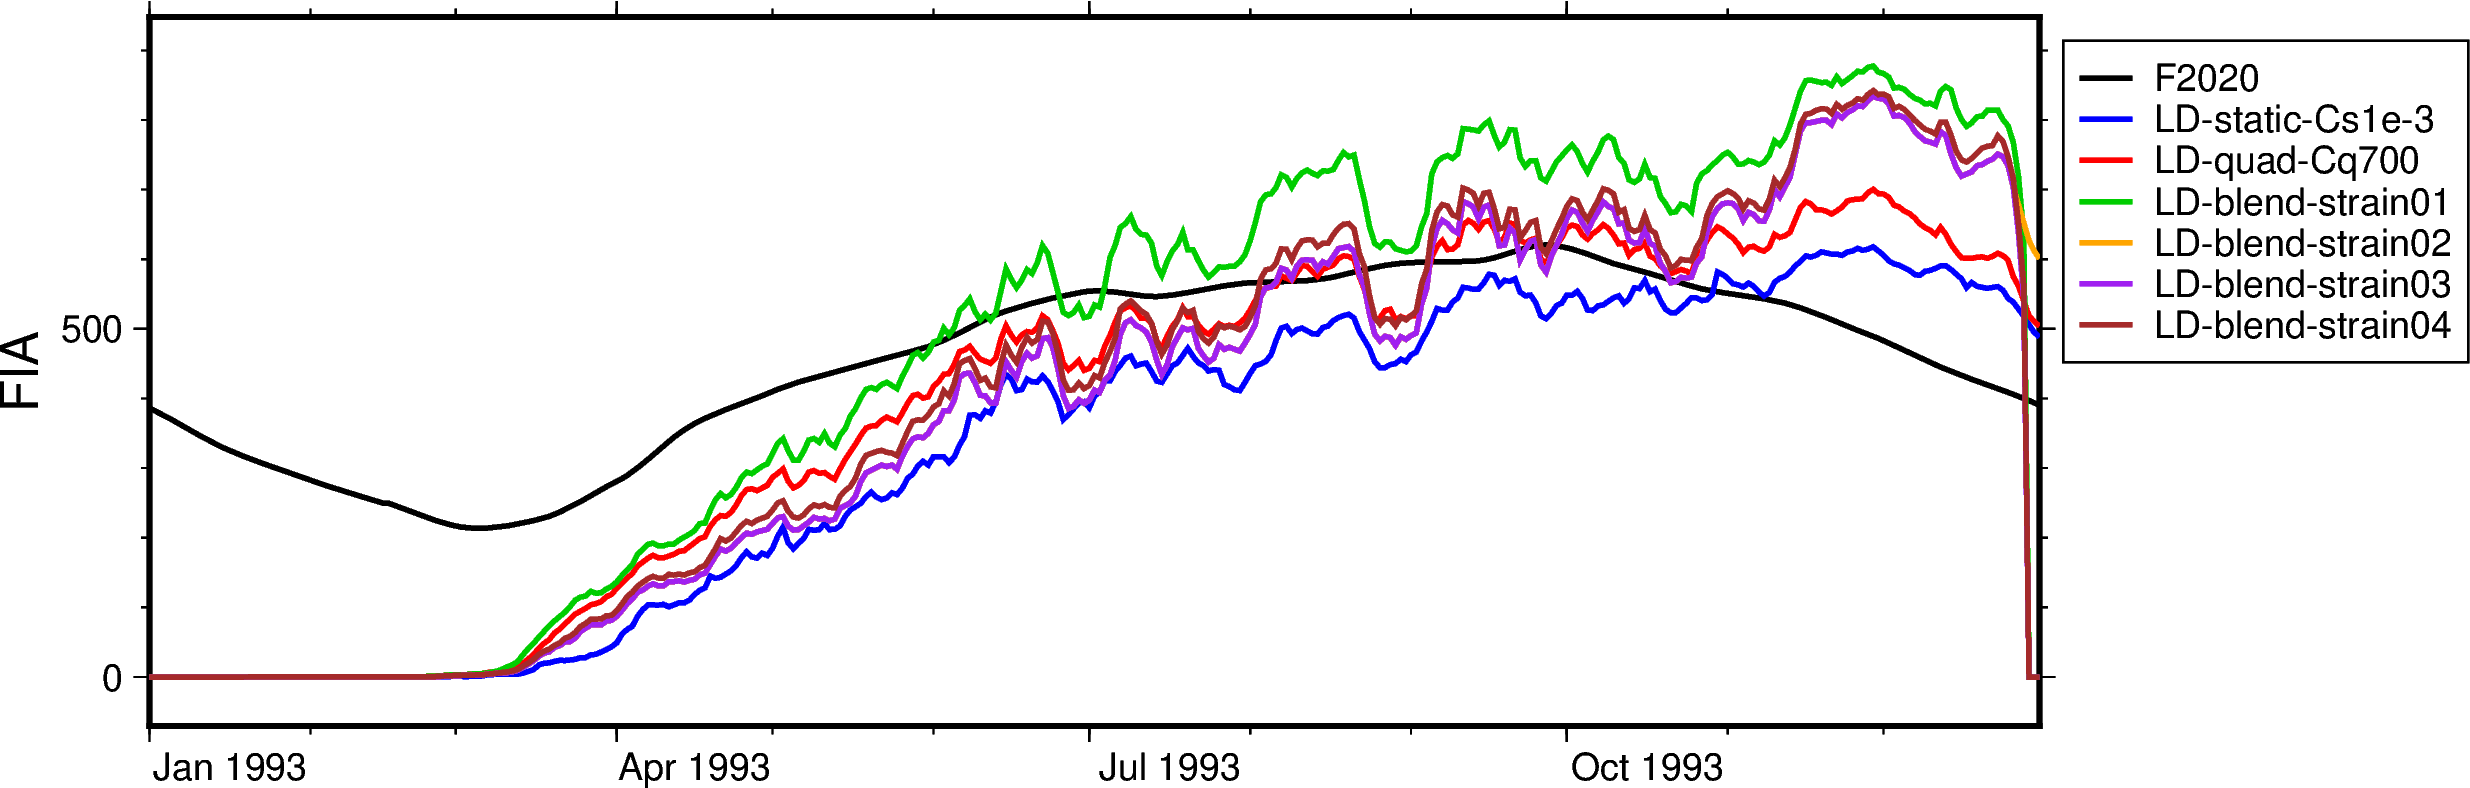

'/g/data/gv90/da1339/GRAPHICAL/AFIM/timeseries/FIA_LD-static-Cs1e-3_LD-quad-Cq700_LD-blend-strain01_LD-blend-strain02_LD-blend-strain03_LD-blend-strain04_1993-01-01_1993-12-31_binary-days_total.png'

In [7]:
from shuga import CICEPlotter
SP = CICEPlotter(run, classify)
SP.plot_timeseries_multi(variable        = "FIA",
                         method          = "binary-days",
                         dt0_str         = "1993-01-01",
                         dtN_str         = "1993-12-31",
                         simulations     = ["LD-static-Cs1e-3", "LD-quad-Cq700", "LD-blend-strain01", "LD-blend-strain02", "LD-blend-strain03", "LD-blend-strain04"],
                         add_f2020       = True,
                         f2020_mode      = "climatology",
                         legend_position = "JTR+jTL+o0.2c",
                         show            = True)

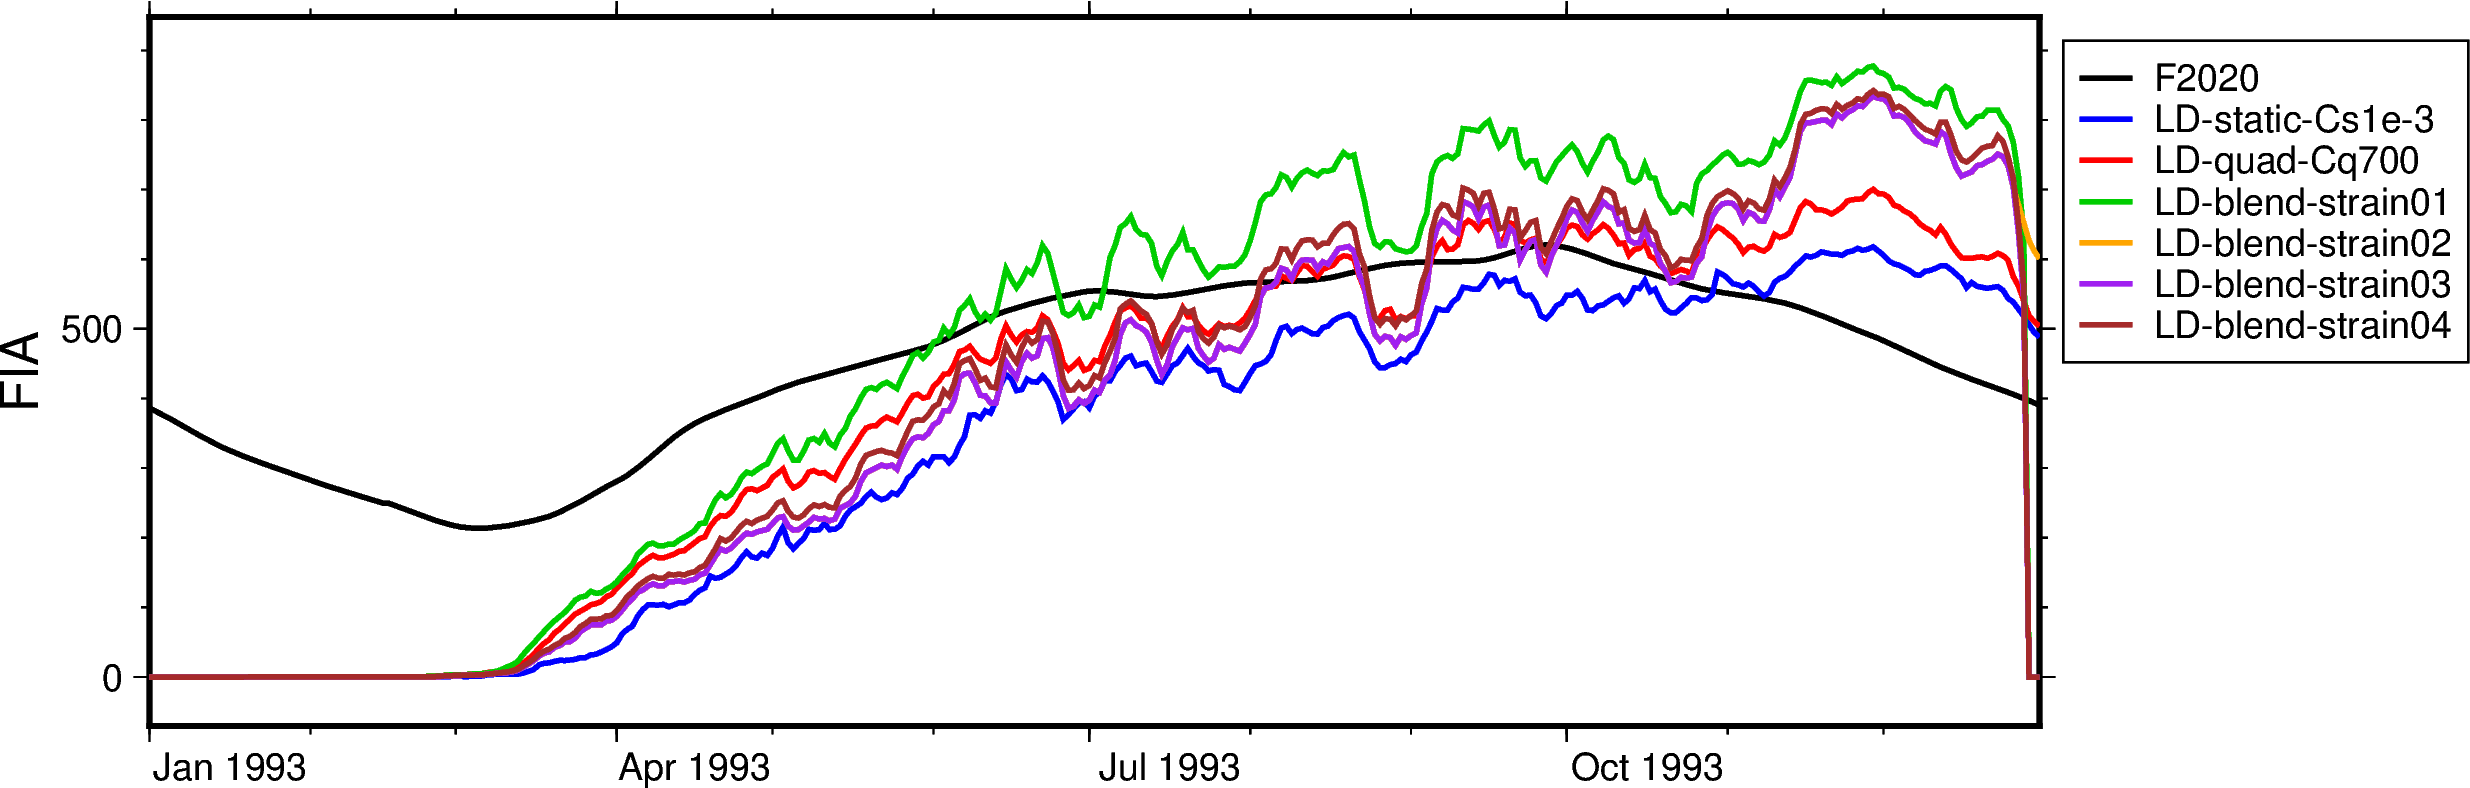

In [8]:
from IPython.display import Image, display
P_png = "/g/data/gv90/da1339/GRAPHICAL/AFIM/timeseries/FIA_LD-static-Cs1e-3_LD-quad-Cq700_LD-blend-strain01_LD-blend-strain02_LD-blend-strain03_LD-blend-strain04_1993-01-01_1993-12-31_binary-days_total.png"
display(Image(filename=P_png))

## FIP

In [9]:
from shuga import (RunSpec, ClassificationSpec, MetricsSpec, PlottingSpec, ObservationSpec, CICEPlotter)
run_cfg = RunSpec(sim_name="LD-static-Cs1e-3", start_date="2000-01-01", end_date="2003-12-31", hemisphere="SH")
cls_cfg = ClassificationSpec(ice_type="FI", methods="binary-days")
met_cfg = MetricsSpec(methods = "binary-days")
plt_cfg = PlottingSpec()
obs_cfg = ObservationSpec()
pltr    = CICEPlotter(run = run_cfg, classify = cls_cfg, metrics = met_cfg, plotting = plt_cfg, observations = obs_cfg) 
#load_classified(run=run, classify=classify, classification="binary-days")
SP       = CICEPlotter(run, classify)
SP.plot_fip(#sim_name    = "LD-static-Cs1e-3",
            method      = "binary-days",)
            #output_root = "/g/data/gv90/da1339/GRAPHICAL/LD-pub-workspace",
            #grid_style  = "c0.25c")

2026-05-26 17:27:58,094 - INFO - [shuga.plotting.plot_fip:449] plot_fip: loading precomputed FIP from metrics store for LD-static-Cs1e-3 (binary-days)
INFO:shuga.io.zarr_loading:Resolving run context.
INFO:shuga.io.zarr_loading:Resolving classification context.
INFO:shuga.io.zarr_loading:Building ShugaPaths.
INFO:shuga.io.zarr_loading:Resolved metrics store for LD-static-Cs1e-3 [Tc/binary-days] by exact path: /home/581/da1339/AFIM_archive/LD-static-Cs1e-3/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr
INFO:shuga.io.zarr_loading:Opening metrics store for LD-static-Cs1e-3 [Tc/binary-days]: /home/581/da1339/AFIM_archive/LD-static-Cs1e-3/zarr/SH/ispd_thresh_5.0e-4/FI/Tc/bin-win-11_bin-min-09/mets.zarr


AttributeError: 'ShugaPaths' object has no attribute 'graphical_root'